[![Open in Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/beykyle/jitr/blob/main/examples/notebooks/qepn_analyzing_power.ipynb)

On Colab the first `import exfor_tools` downloads and unpacks the EXFOR database, which takes a few minutes.

In [1]:
# Google Colab setup: installs jitr and this notebook's extra dependencies.
# Does nothing when the notebook is run anywhere else.
import sys

if "google.colab" in sys.modules:
    import subprocess

    subprocess.run(
        [sys.executable, "-m", "pip", "install", "-q", "jitr", "exfor-tools"],
        check=True,
    )

# Analyzing power of the quasi-elastic $(\vec{p},n)$ reaction

In 1976 Gosset, Mayer and Escudié measured the differential analyzing power $A_y(\theta)$ of
the quasi-elastic $(p,n)$ reaction to the isobaric analog state (IAS) on nine targets, with a
22.8 MeV polarized proton beam at Saclay
([Phys. Rev. C **14**, 878](https://doi.org/10.1103/PhysRevC.14.878)).
Those data are EXFOR entry [O0669](https://www-nds.iaea.org/exfor/servlet/X4sGetSubent?reqx=51740&subID=O0669).

Their point was that $A_y$ is a far sharper probe of the Lane potential than the cross section is.
In the macroscopic Lane model the nucleon-nucleus optical potential splits into isoscalar and
isovector parts,

$$ U = U_0 + \frac{4}{A} U_1\, \vec{t} \cdot \vec{T}, $$

which for the proton-target, neutron-analog and neutron-target channels gives

$$ U_{pT} = U_0 - \frac{2 T_0}{A} U_1, \qquad
   U_{nA} = U_0 + \frac{2 (T_0 - 1)}{A} U_1, \qquad
   U_{nT} = U_0 + \frac{2 T_0}{A} U_1, $$

with $T_0 = (N - Z)/2$. The off-diagonal part of $U_1$ drives the charge-exchange transition
between $|T_0 T_0\rangle$ and its analog $|T_0, T_0 - 1\rangle$. Because the transition carries
$l = s = j = 0$, only two amplitudes survive — one conserving and one inverting the projectile
spin projection — and the analyzing power is

$$ A_y = \frac{2\,\mathrm{Im}(Y X^*)}{|X|^2 + |Y|^2}. $$

The spin-flip amplitude $Y$ is built from the *difference* between the $j = l + \tfrac{1}{2}$ and
$j = l - \tfrac{1}{2}$ radial matrix elements. If the entrance and exit distorting spin-orbit
potentials both vanish, those matrix elements stop depending on $j$, $Y$ vanishes, and
$A_y \equiv 0$ identically. So $A_y$ measures spin-orbit physics and almost nothing else — which
is why Gosset *et al.* used it to try to pin down the isovector spin-orbit depth $V^{(1)}_{so}$.

This notebook solves the two coupled Lane channels exactly with
[`jitr.xs.lane_pn`](https://jitr.readthedocs.io/en/latest/autoapi/jitr/xs/lane_pn/index.html)
rather than in DWBA, and propagates the posteriors of three uncertainty-quantified global optical
potentials — KDUQ, WLH and CHUQ — plus a deterministic JLMB calculation, through to $A_y$ for all
nine targets.

A note on the targets: $^{49}$Ti, $^{117}$Sn and $^{165}$Ho have non-zero ground-state spin, but the
transition transfers no angular momentum, so the target spin is a spectator and the spin-1/2
geometry used here still applies.

In [2]:
import os

import matplotlib.pyplot as plt
import numpy as np
import periodictable

import jitr
from jitr.folding import ILDAFolder
from jitr.folding.jlm import (
    lambda_v0,
    lambda_v1,
    lambda_vso,
    lambda_w0,
    lambda_w1,
    lambda_wso,
    potential_JLMB,
    spin_orbit_jlmb,
)
from jitr.optical_potentials import chuq, kduq, wlh
from jitr.utils.density import density_table
from jitr.xs import lane_pn, quasielastic_pn

# set JITR_QUICK=1 to thin the posterior draws; used by the CI notebook run
QUICK = os.environ.get("JITR_QUICK", "0") == "1"

## Pulling the measurements from EXFOR

Each of the nine targets is a subentry of O0669, tabulated as an analyzing power against the
center-of-mass angle, together with the excitation energy of the analog state in the residual
nucleus. That excitation energy is what fixes the outgoing neutron energy, so we read it from the
entry rather than hard-coding it.

In [3]:
from exfor_tools import ExforEntry
from exfor_tools.parsing import quantity_matches, quantity_symbols
from exfor_tools.reaction import Reaction as ExforReaction

# exfor-tools <= 1.2 maps "Ay" only to ["POL/DA", "ANA"], but EXFOR qualifies a measurement
# resolved to a particular level of the residual with "PAR" -- as it must for a transition to
# the analog state. Fixed upstream, so this is a no-op against a newer exfor-tools.
par_ay = ["PAR", "POL/DA", "ANA"]
if par_ay not in quantity_matches["Ay"]:
    quantity_matches["Ay"].append(par_ay)
    quantity_symbols[tuple(par_ay)] = r"$A_y$"

# the nine targets of Table I, in the order the paper presents them
TARGETS = [
    (49, 22),
    (56, 26),
    (64, 28),
    (70, 30),
    (90, 40),
    (96, 40),
    (117, 50),
    (165, 67),
    (208, 82),
]
PROTON, NEUTRON = (1, 1), (1, 0)


def nuclide(A, Z):
    return rf"$^{{{A}}}${periodictable.elements[Z].symbol}"


datasets = []
for A, Z in TARGETS:
    entry = ExforEntry(
        "O0669",
        ExforReaction(
            target=(A, Z), projectile=PROTON, product=NEUTRON, residual=(A, Z + 1)
        ),
        quantity="Ay",
    )
    (measurement,) = entry.measurements
    datasets.append(
        {
            "A": A,
            "Z": Z,
            "name": f"{A}{periodictable.elements[Z].symbol}",
            "residual_name": f"{A}{periodictable.elements[Z + 1].symbol}",
            "label": nuclide(A, Z),
            "subentry": measurement.subentry,
            "E_lab": measurement.Einc,
            "E_IAS": measurement.Ex,
            "theta": measurement.x,
            "Ay": measurement.y,
            "Ay_err": measurement.statistical_err,
        }
    )

print(entry.bibtex())

Using database version X4-2024-12-31 located in: /home/kyle/db/exfor/unpack_exfor-2024/X4-2024-12-31


@article{JGosset1976_O0669001,
  author = {J.Gosset and B.Mayer and J.L.Escudie},
  title = {Quasielastic (P,N) Reactions Induced By Polarized Protons.},
  journal = {Physical Review, Part C, Nuclear Physics},
  year = {1976},
  volume = {14},
  pages = {878},
  note = {EXFOR reference: Physical Review, Part C, Nuclear Physics 14, 878 (1976); EXFOR subent: O0669001}
}


In [4]:
header = f"{'target':>8} {'residual':>10} {'subentry':>10} {'E_IAS [MeV]':>12} {'points':>7} {'angular range [deg]':>22}"
print(header)
print("-" * len(header))
for d in datasets:
    angles = f"{d['theta'][0]:.1f} - {d['theta'][-1]:.1f}"
    print(
        f"{d['name']:>8} {d['residual_name']:>10} {d['subentry']:>10} "
        f"{d['E_IAS']:>12.2f} {len(d['theta']):>7} {angles:>22}"
    )
print(
    f"\n{sum(len(d['theta']) for d in datasets)} points, all at E_p = {datasets[0]['E_lab']} MeV"
)

  target   residual   subentry  E_IAS [MeV]  points    angular range [deg]
--------------------------------------------------------------------------
    49Ti        49V   O0669002         5.36      18           16.6 - 103.2
    56Fe       56Co   O0669003         3.51      23           15.7 - 125.1
    64Ni       64Cu   O0669004         6.70      19           16.7 - 106.4
    70Zn       70Ga   O0669005         8.12      20           16.0 - 114.3
    90Zr       90Nb   O0669006         5.03      22           15.4 - 124.3
    96Zr       96Nb   O0669007        11.07      18            14.4 - 98.7
   117Sn      117Sb   O0669008        11.18      17            15.0 - 94.9
   165Ho      165Er   O0669009        15.49       8            16.9 - 61.0
   208Pb      208Bi   O0669010        15.33       4            17.3 - 31.4

149 points, all at E_p = 22.8 MeV


## Building one coupled-channels workspace per target

`jitr.xs.lane_pn.Workspace` solves the two-channel problem

$$ \left[T_l + U_{pp} - E_p\right] u_p + U_1 u_n = 0, \qquad
   \left[T_l + U_{nn} - E_n\right] u_n + U_1 u_p = 0 $$

for every $(l, j)$, with an incoming wave in the proton channel only. The two channels have
different wavenumbers, reduced masses and Sommerfeld parameters but share one physical channel
radius, and the R-matrix solution gives the full $2 \times 2$ S-matrix, whose off-diagonal element
is the charge-exchange amplitude.

The exit channel needs its own `Reaction` so that the neutron optical potential is evaluated on the
*residual* nucleus rather than on the target. Building the solvers and workspaces in their own cell
keeps the numba compilation and the Lagrange-mesh precompute out of the sample loop below.

In [5]:
E_LAB = 22.8
LMAX = 25
ANGLES = np.radians(np.linspace(1.0, 180.0, 180))

solvers = {}
for d in datasets:
    A, Z = d["A"], d["Z"]
    reaction = jitr.reactions.Reaction(
        target=(A, Z), projectile=PROTON, product=NEUTRON, residual=(A, Z + 1)
    )
    # "El" so that the neutron potential is evaluated for n + residual
    exit_reaction = jitr.reactions.Reaction(
        target=(A, Z + 1), projectile=NEUTRON, process="El"
    )
    kinematics_entrance = reaction.kinematics(E_LAB)
    kinematics_exit = reaction.kinematics_exit(
        kinematics_entrance, residual_excitation_energy=d["E_IAS"]
    )

    a = jitr.utils.interaction_range(A) * kinematics_entrance.k + 2 * np.pi
    nbasis = jitr.utils.suggested_basis_size(a)
    solver = solvers.setdefault(nbasis, jitr.rmatrix.Solver(nbasis))

    d.update(
        reaction=reaction,
        exit_reaction=exit_reaction,
        kinematics_entrance=kinematics_entrance,
        kinematics_exit=kinematics_exit,
        nbasis=nbasis,
        channel_radius_fm=a / kinematics_entrance.k,
        workspace=lane_pn.Workspace(
            reaction,
            kinematics_entrance,
            kinematics_exit,
            solver,
            ANGLES,
            LMAX,
            a / kinematics_entrance.k,
        ),
    )

for d in datasets:
    print(
        f"{d['name']:>8}  E_n = {d['kinematics_exit'].Elab:5.2f} MeV  "
        f"a = {d['channel_radius_fm']:5.2f} fm  nbasis = {d['nbasis']:2d}"
    )

    49Ti  E_n = 15.92 MeV  a = 10.47 fm  nbasis = 20
    56Fe  E_n = 13.78 MeV  a = 10.66 fm  nbasis = 20
    64Ni  E_n = 13.50 MeV  a = 10.85 fm  nbasis = 20
    70Zn  E_n = 13.11 MeV  a = 10.99 fm  nbasis = 20
    90Zr  E_n = 10.74 MeV  a = 11.40 fm  nbasis = 20
    96Zr  E_n = 10.99 MeV  a = 11.52 fm  nbasis = 20
   117Sn  E_n =  8.96 MeV  a = 11.88 fm  nbasis = 20
   165Ho  E_n =  6.05 MeV  a = 12.58 fm  nbasis = 25
   208Pb  E_n =  3.72 MeV  a = 13.10 fm  nbasis = 25


## Checking convergence

The isovector coupling is weak, so the charge-exchange S-matrix element falls off quickly with $l$
and the calculation converges at modest $l_{max}$ and basis size. Doubling $l_{max}$ and enlarging
the channel radius move $A_y$ by less than $4 \times 10^{-3}$ in absolute terms, on a quantity
bounded by 1 — though note that near a zero crossing that is not a small *relative* shift, and this
checks one target rather than all nine. The distorting potentials here are the original frequentist
Koning-Delaroche parameters; the posterior draws below are no harder to converge.

In [6]:
reference = datasets[1]  # 56Fe
omp_p, omp_n = kduq.KDUQ(PROTON), kduq.KDUQ(NEUTRON)
# the original frequentist Koning-Delaroche set, not a central value of the KDUQ posterior
params_p = kduq.get_kd03(PROTON)
params_n = kduq.get_kd03(NEUTRON)


def ay_at(lmax, channel_radius_fm, nbasis):
    workspace = lane_pn.Workspace(
        reference["reaction"],
        reference["kinematics_entrance"],
        reference["kinematics_exit"],
        jitr.rmatrix.Solver(nbasis),
        ANGLES,
        lmax,
        channel_radius_fm,
    )
    rgrid = workspace.radial_grid()
    U_p, U_p_so, U_coulomb = omp_p(
        rgrid, reference["reaction"], reference["kinematics_entrance"], *params_p
    )
    U_n, U_n_so, _ = omp_n(
        rgrid, reference["exit_reaction"], reference["kinematics_exit"], *params_n
    )
    return workspace.observables(U_coulomb, U_p, U_p_so, U_n, U_n_so).Ay


baseline = ay_at(LMAX, reference["channel_radius_fm"], reference["nbasis"])
print(
    f"{reference['name']}, relative to lmax={LMAX}, a={reference['channel_radius_fm']:.2f} fm, nbasis={reference['nbasis']}"
)
for lmax, a_fm, nbasis in [
    (LMAX, reference["channel_radius_fm"], reference["nbasis"] + 10),
    (40, reference["channel_radius_fm"], reference["nbasis"]),
    (40, 16.0, 35),
]:
    shift = np.max(np.absolute(ay_at(lmax, a_fm, nbasis) - baseline))
    print(
        f"  lmax={lmax:3d}  a={a_fm:5.2f} fm  nbasis={nbasis:3d}   max |dAy| = {shift:.2e}"
    )

56Fe, relative to lmax=25, a=10.66 fm, nbasis=20
  lmax= 25  a=10.66 fm  nbasis= 30   max |dAy| = 3.77e-03


  lmax= 40  a=10.66 fm  nbasis= 20   max |dAy| = 0.00e+00


  lmax= 40  a=16.00 fm  nbasis= 35   max |dAy| = 3.90e-03


## Propagating the optical model posteriors

KDUQ, WLH and CHUQ each ship a posterior sample of their parameter vectors, so a predictive band
for $A_y$ is one solve per draw. Nothing here is a fit to these data: the potentials were
calibrated to elastic scattering, and the Lane transition potential is taken to be the default
isovector difference

$$ U_1 = -\left(U_n - U_p\right) \frac{\sqrt{|N - Z|}}{N - Z - 1}, $$

evaluated separately for the central and spin-orbit terms — so the isovector spin-orbit form factor
that the analyzing power is sensitive to comes entirely from the difference between the proton and
neutron spin-orbit potentials of each global parameterization.

CHUQ deserves a word: CH89 is Lane-consistent by construction, so it is the one built-in whose
proton and neutron potentials really are the $U_{pT}$ and $U_{nA}$ of the equations above, and
whose difference therefore really is $U_1$. For KDUQ and WLH the same construction is an
approximation, and the diagonal potentials may already absorb part of the coupling.

In [7]:
OMPS = {
    "KDUQ": (
        kduq.KDUQ(PROTON),
        kduq.KDUQ(NEUTRON),
        kduq.get_samples(PROTON),
        kduq.get_samples(NEUTRON),
    ),
    "WLH": (
        wlh.WLH(PROTON),
        wlh.WLH(NEUTRON),
        wlh.get_samples(PROTON),
        wlh.get_samples(NEUTRON),
    ),
    # CH89 is Lane consistent: one parameter set serves both projectiles
    "CHUQ": (chuq.CHUQ(), chuq.CHUQ(), chuq.get_samples(), chuq.get_samples()),
}


def propagate(omp_p, omp_n, samples_p, samples_n):
    n_draws = min(len(samples_p), len(samples_n))
    if QUICK:
        n_draws = min(n_draws, 50)

    bands = []
    for d in datasets:
        workspace = d["workspace"]
        rgrid = workspace.radial_grid()
        Ay = np.zeros((len(ANGLES), n_draws))
        dsdo = np.zeros((len(ANGLES), n_draws))
        for j in range(n_draws):
            U_p, U_p_so, U_coulomb = omp_p(
                rgrid, d["reaction"], d["kinematics_entrance"], *samples_p[j]
            )
            U_n, U_n_so, _ = omp_n(
                rgrid, d["exit_reaction"], d["kinematics_exit"], *samples_n[j]
            )
            _, S = workspace.rsmatrix(U_coulomb, U_p, U_p_so, U_n, U_n_so)
            observables = workspace.observables_from_smatrix(S)
            Ay[:, j] = observables.Ay
            dsdo[:, j] = observables.dsdo
        bands.append(
            {
                "Ay": np.percentile(Ay, [16, 84], axis=1),
                "Ay_median": np.median(Ay, axis=1),
                "dsdo": np.percentile(dsdo, [16, 84], axis=1),
                "dsdo_median": np.median(dsdo, axis=1),
            }
        )
    return n_draws, bands


predictions = {}
for name, args in OMPS.items():
    n_draws, bands = propagate(*args)
    predictions[name] = bands
    print(f"{name}: {n_draws} posterior draws x {len(datasets)} targets")

/home/kyle/umich/jitr/src/jitr/optical_potentials/kduq.py:470: RuntimeWarning: overflow encountered in exp
  d2 = d2_0 + d2_A / (1 + np.exp((A - d2_A3) / d2_A2))


KDUQ: 416 posterior draws x 9 targets


WLH: 1000 posterior draws x 9 targets


CHUQ: 208 posterior draws x 9 targets


## A semi-microscopic comparison: JLMB

JLMB is a different kind of potential: a local-density folding of the Jeukenne-Lejeune-Mahaux
nuclear-matter *g*-matrix over a Gogny D1M density, with energy-dependent normalizations
$\lambda_V, \lambda_W, \lambda_{V_1}, \lambda_{W_1}$ and a Scheerbaum spin-orbit form factor. It is
the one potential here with a genuine isovector form factor rather than one obtained by
differencing — but it ships no posterior sample, so what follows is a single curve, not a band.

In [8]:
def jlmb_potentials(d):
    workspace = d["workspace"]
    rgrid = workspace.radial_grid()
    folder = ILDAFolder(r_max=15.0, n_quad=200)

    def channel(A, Z, projectile, energy, coulomb):
        table = density_table(A, Z, model="d1m")
        rho_n = folder.interp_to_quad(table.radial_grid, table.neutron_density_grid)
        rho_p = folder.interp_to_quad(table.radial_grid, table.proton_density_grid)
        V_C_quad = folder.V_coulomb(rho_p) if coulomb else None
        V, W = potential_JLMB(
            folder,
            rho_n,
            rho_p,
            projectile,
            (A, Z),
            energy,
            V_C=V_C_quad,
            parameterization="talys",
            lambda_V=float(lambda_v0(energy)),
            lambda_W=float(lambda_w0(energy, mode=0)),
            lambda_V1=float(lambda_v1(energy)),
            lambda_W1=float(lambda_w1(energy, mode=0)),
            t_r=1.25,
            t_i=1.35,
            r_out=rgrid,
        )
        spin_orbit = (
            float(lambda_vso(energy)) + 1j * float(lambda_wso(energy))
        ) * spin_orbit_jlmb(folder.r_q, rho_n, rho_p, projectile, r_out=rgrid)
        coulomb_out = folder.V_coulomb(rho_p, r_out=rgrid) if coulomb else None
        return (
            np.asarray(V + 1j * W, dtype=np.complex128),
            np.asarray(spin_orbit, dtype=np.complex128),
            (
                None
                if coulomb_out is None
                else np.asarray(coulomb_out, dtype=np.complex128)
            ),
        )

    U_p, U_p_so, U_coulomb = channel(
        d["A"], d["Z"], PROTON, d["kinematics_entrance"].Elab, coulomb=True
    )
    U_n, U_n_so, _ = channel(
        d["A"], d["Z"] + 1, NEUTRON, d["kinematics_exit"].Elab, coulomb=False
    )
    return U_coulomb, U_p, U_p_so, U_n, U_n_so


jlmb = []
for d in datasets:
    jlmb.append(d["workspace"].observables(*jlmb_potentials(d)))
print(f"JLMB evaluated for {len(jlmb)} targets")

JLMB evaluated for 9 targets


## The measurements against the calculations

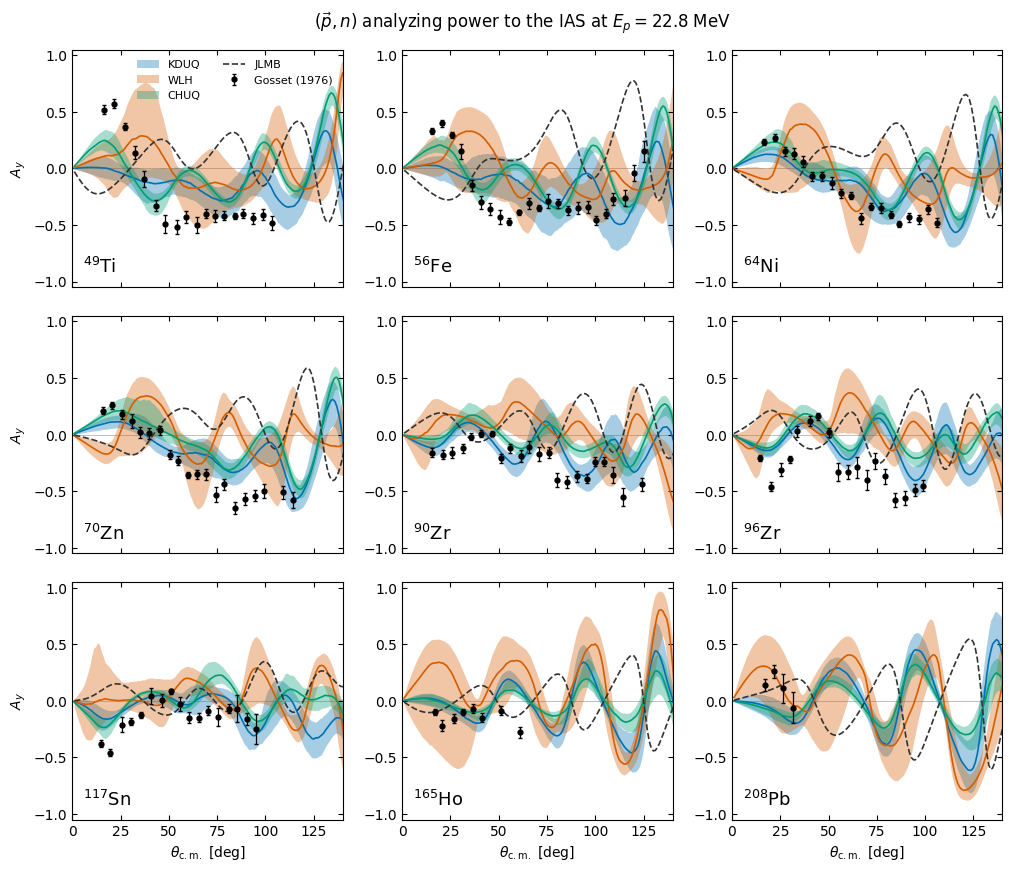

In [9]:
BANDS = {"KDUQ": "#0072B2", "WLH": "#D55E00", "CHUQ": "#009E73"}
JLMB_INK = "#333333"
angles_deg = np.degrees(ANGLES)


def grid_figure(ylabel):
    fig, axes = plt.subplots(3, 3, figsize=(12, 10), sharex=True)
    fig.subplots_adjust(hspace=0.12, wspace=0.22)
    for ax in axes[-1]:
        ax.set_xlabel(r"$\theta_{\rm c.m.}$ [deg]")
    for ax in axes[:, 0]:
        ax.set_ylabel(ylabel)
    for ax in axes.flat:
        ax.set_xlim(0, 140)
        ax.tick_params(direction="in", top=True, right=True)
        for side in ax.spines.values():
            side.set_linewidth(0.8)
    return fig, axes


fig, axes = grid_figure(r"$A_y$")
for i, (ax, d, curve) in enumerate(zip(axes.flat, datasets, jlmb, strict=True)):
    for name, color in BANDS.items():
        lo, hi = predictions[name][i]["Ay"]
        ax.fill_between(angles_deg, lo, hi, color=color, alpha=0.35, lw=0, label=name)
        ax.plot(angles_deg, predictions[name][i]["Ay_median"], color=color, lw=1.2)
    ax.plot(angles_deg, curve.Ay, color=JLMB_INK, lw=1.2, ls="--", label="JLMB")
    ax.errorbar(
        d["theta"],
        d["Ay"],
        yerr=d["Ay_err"],
        fmt="o",
        ms=3.5,
        color="k",
        lw=0.9,
        capsize=1.5,
        label="Gosset (1976)",
    )
    ax.axhline(0.0, color="0.75", lw=0.7, zorder=0)
    ax.set_ylim(-1.05, 1.05)
    ax.text(0.04, 0.06, d["label"], transform=ax.transAxes, fontsize=13)

axes[0, 0].legend(loc="upper right", fontsize=8, frameon=False, ncols=2)
fig.suptitle(r"$(\vec{p},n)$ analyzing power to the IAS at $E_p = 22.8$ MeV", y=0.92)
plt.show()

In [10]:
# two numbers per target: the analyzing power at the most forward measured angle,
# whose sign is the feature Gosset et al. tracked across the mass range, and the
# mean over the measured angles beyond 40 deg, where the data sit on a plateau
def summarize(theta, curve):
    interpolated = np.interp(theta, angles_deg, curve)
    plateau = interpolated[theta > 40.0]
    # 208Pb has no measured point beyond 40 degrees
    return interpolated[0], plateau.mean() if plateau.size else np.nan


models = list(BANDS) + ["JLMB"]
print(f"{'':>8} {'theta_1':>8} | {'Ay(theta_1)':>34} | {'<Ay> for theta > 40 deg':>34}")
print(
    f"{'target':>8} {'[deg]':>8} | "
    + " ".join(f"{m:>8}" for m in ["data"] + models)
    + " | "
    + " ".join(f"{m:>8}" for m in ["data"] + models)
)
print("-" * 98)
for i, d in enumerate(datasets):
    curves = [predictions[name][i]["Ay_median"] for name in BANDS] + [jlmb[i].Ay]
    measured_plateau = d["Ay"][d["theta"] > 40.0]
    forward = [d["Ay"][0]] + [summarize(d["theta"], c)[0] for c in curves]
    if measured_plateau.size:
        plateau = [measured_plateau.mean()] + [
            summarize(d["theta"], c)[1] for c in curves
        ]
        plateau = " ".join(f"{value:>8.2f}" for value in plateau)
    else:
        plateau = " ".join(f"{'--':>8}" for _ in range(len(curves) + 1))
    print(
        f"{d['name']:>8} {d['theta'][0]:>8.1f} | "
        + " ".join(f"{value:>8.2f}" for value in forward)
        + " | "
        + plateau
    )

          theta_1 |                        Ay(theta_1) |            <Ay> for theta > 40 deg
  target    [deg] |     data     KDUQ      WLH     CHUQ     JLMB |     data     KDUQ      WLH     CHUQ     JLMB
--------------------------------------------------------------------------------------------------
    49Ti     16.6 |     0.52     0.00     0.11     0.25    -0.21 |    -0.44    -0.16    -0.07    -0.10     0.11
    56Fe     15.7 |     0.33     0.03     0.05     0.18    -0.22 |    -0.31    -0.20    -0.09    -0.11     0.24
    64Ni     16.7 |     0.23     0.12    -0.09     0.21    -0.18 |    -0.32    -0.18    -0.10    -0.09     0.15
    70Zn     16.0 |     0.21     0.09    -0.17     0.16    -0.08 |    -0.41    -0.23    -0.04    -0.13     0.16
    90Zr     15.4 |    -0.16    -0.11     0.07    -0.04     0.17 |    -0.26    -0.14     0.06    -0.06     0.10
    96Zr     14.4 |    -0.20    -0.13    -0.04    -0.11     0.16 |    -0.29    -0.10     0.10    -0.01     0.04
   117Sn     15.0 |    -0

Compare with Figs. 4, 6 and 8 of the paper, and with the table above.

The feature Gosset *et al.* tracked across the mass range is the sign of the forward extremum,
sampled in the table at the most forward measured angle, 15-17$^\circ$: positive for the
medium-mass targets and negative for the heavier ones. In the data it runs
$+0.52, +0.33, +0.23, +0.21$ for $^{49}$Ti, $^{56}$Fe, $^{64}$Ni, $^{70}$Zn and then
$-0.16, -0.20, -0.38$ for $^{90}$Zr, $^{96}$Zr, $^{117}$Sn. CHUQ reproduces all seven signs and
KDUQ six, with $^{49}$Ti sitting at zero. Both also get the negative plateau beyond 40$^\circ$,
KDUQ at roughly half the observed depth and CHUQ at about a quarter of it. That is the same
failure mode the paper reported for its own best DWBA calculations: right phase, too small an
amplitude. WLH does not reproduce the changeover at all, and its band is several times wider than
the other two throughout.

Two panels should not be read as tests of the model, and the paper says as much: $^{165}$Ho is
strongly deformed, so a spherical Lane model is the wrong tool, and $^{208}$Pb has four points with
an exit neutron energy of 3.7 MeV, where the compound-nucleus contribution cannot be neglected.
They are also the two targets whose forward extremum KDUQ and CHUQ fail to reproduce — flat against
$-0.10$ for $^{165}$Ho, and the wrong sign for $^{208}$Pb.

The JLMB curve is the interesting outlier: its analyzing power comes out with the opposite sign to
both phenomenological potentials and to the data, over most of the angular range and for most
targets. Since $A_y$ here is driven almost entirely by the isovector spin-orbit form factor, and
JLMB is the one potential whose spin-orbit is a Scheerbaum form factor rather than a fitted
Woods-Saxon derivative, this says something about the isovector content of that form factor rather
than about the coupled-channels solution. It is recorded here as an observation, not a result.

The same S-matrices give the cross section, which — as the paper emphasized — is far less
discriminating. There are no cross-section data in this EXFOR entry; the paper compared against a
separate Boulder measurement.

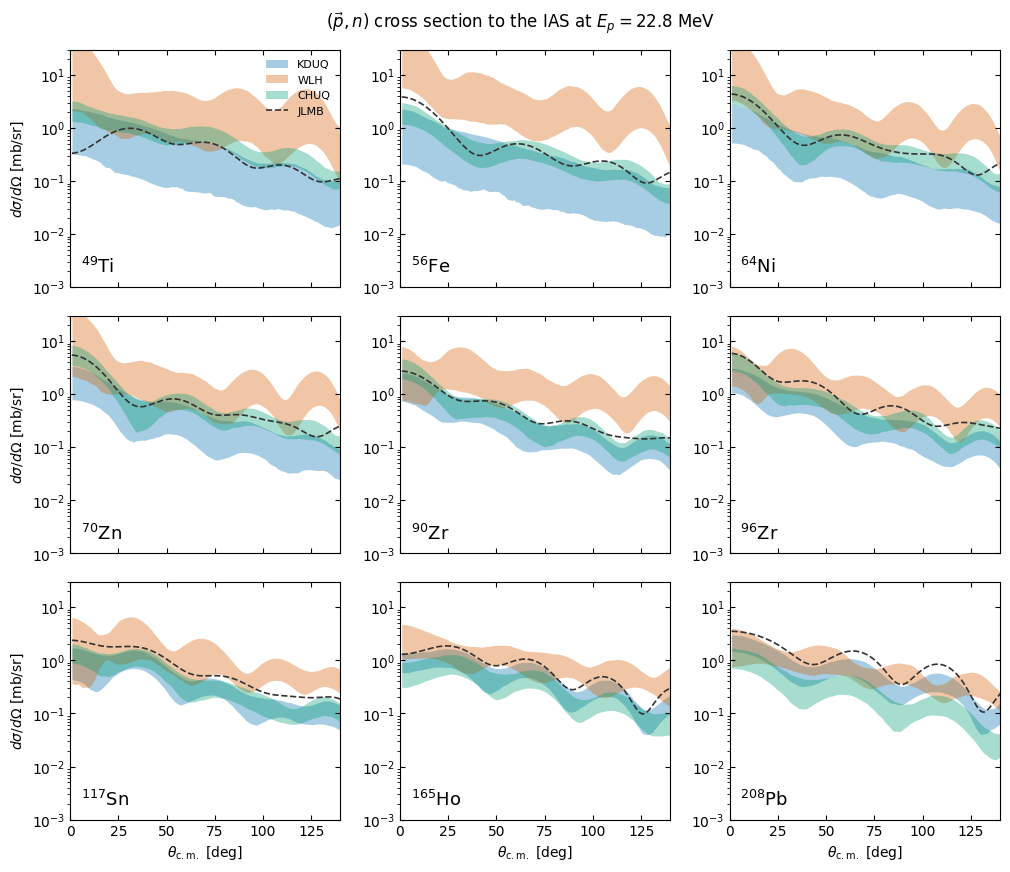

In [11]:
fig, axes = grid_figure(r"$d\sigma/d\Omega$ [mb/sr]")
for i, (ax, d, curve) in enumerate(zip(axes.flat, datasets, jlmb, strict=True)):
    for name, color in BANDS.items():
        lo, hi = predictions[name][i]["dsdo"]
        ax.fill_between(angles_deg, lo, hi, color=color, alpha=0.35, lw=0, label=name)
    ax.plot(angles_deg, curve.dsdo, color=JLMB_INK, lw=1.2, ls="--", label="JLMB")
    ax.set_yscale("log")
    ax.set_ylim(1e-3, 3e1)
    ax.text(0.04, 0.06, d["label"], transform=ax.transAxes, fontsize=13)

axes[0, 0].legend(loc="upper right", fontsize=8, frameon=False)
fig.suptitle(r"$(\vec{p},n)$ cross section to the IAS at $E_p = 22.8$ MeV", y=0.92)
plt.show()

## How much does the exact coupling matter?

The first-order approximation to the off-diagonal S-matrix element is the DWBA of
`jitr.xs.quasielastic_pn`. Feeding both workspaces the same potentials isolates the effect of
solving the coupled system exactly rather than to first order in $U_1$.

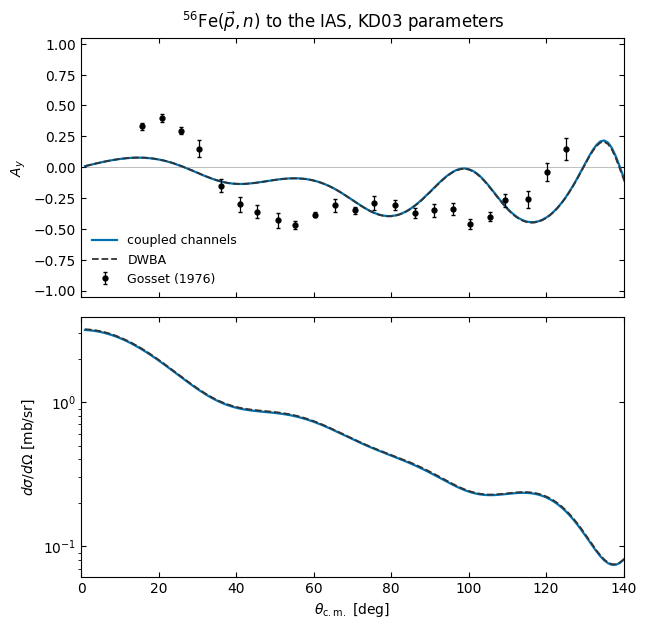

max |Ay(CC) - Ay(DWBA)| = 0.0162
max relative cross-section difference = 0.0266


In [12]:
d = reference
workspace_dwba = quasielastic_pn.Workspace(
    d["reaction"],
    d["kinematics_entrance"],
    d["kinematics_exit"],
    jitr.rmatrix.Solver(d["nbasis"]),
    ANGLES,
    LMAX,
    d["channel_radius_fm"],
    tmatrix_abs_tol=0.0,
)
rgrid = d["workspace"].radial_grid()
U_p, U_p_so, U_coulomb = omp_p(
    rgrid, d["reaction"], d["kinematics_entrance"], *params_p
)
U_n, U_n_so, _ = omp_n(rgrid, d["exit_reaction"], d["kinematics_exit"], *params_n)

cc = d["workspace"].observables(U_coulomb, U_p, U_p_so, U_n, U_n_so)
dwba = workspace_dwba.observables(U_coulomb, U_p, U_p_so, U_n, U_n_so)

fig, (ax_ay, ax_xs) = plt.subplots(
    2, 1, figsize=(7, 7), sharex=True, height_ratios=[1, 1]
)
fig.subplots_adjust(hspace=0.08)
for ax, cc_y, dwba_y in [(ax_ay, cc.Ay, dwba.Ay), (ax_xs, cc.dsdo, dwba.dsdo)]:
    ax.plot(angles_deg, cc_y, color="#0072B2", lw=1.6, label="coupled channels")
    ax.plot(angles_deg, dwba_y, color=JLMB_INK, lw=1.3, ls="--", label="DWBA")
    ax.tick_params(direction="in", top=True, right=True)
ax_ay.errorbar(
    d["theta"],
    d["Ay"],
    yerr=d["Ay_err"],
    fmt="o",
    ms=3.5,
    color="k",
    lw=0.9,
    capsize=1.5,
    label="Gosset (1976)",
)
ax_ay.axhline(0.0, color="0.75", lw=0.7, zorder=0)
ax_ay.set_ylabel(r"$A_y$")
ax_ay.set_ylim(-1.05, 1.05)
ax_ay.legend(loc="lower left", fontsize=9, frameon=False)
ax_xs.set_yscale("log")
ax_xs.set_ylabel(r"$d\sigma/d\Omega$ [mb/sr]")
ax_xs.set_xlabel(r"$\theta_{\rm c.m.}$ [deg]")
ax_xs.set_xlim(0, 140)
fig.suptitle(rf"{d['label']}$(\vec{{p}},n)$ to the IAS, KD03 parameters", y=0.92)
plt.show()

print(f"max |Ay(CC) - Ay(DWBA)| = {np.max(np.absolute(cc.Ay - dwba.Ay)):.4f}")
print(
    f"max relative cross-section difference = {np.max(np.absolute(cc.dsdo / dwba.dsdo - 1)):.4f}"
)

## Summary

Propagating three uncertainty-quantified global optical potentials through an exact
coupled-channels Lane calculation reproduces the qualitative structure of the Gosset *et al.*
analyzing powers without any adjustment to these data. For KDUQ and CHUQ the sign of the forward
extremum and its mass dependence come out right, and so does the sign of the mid-angle plateau —
but at about half the measured depth, and the posterior bands nowhere near cover the data.

That gap is the point of the original paper. The analyzing power of a quasi-elastic $(p,n)$
reaction depends on the isovector spin-orbit part of the Lane potential, which global elastic
analyses barely constrain. Here it is not a fitted quantity at all: it is the difference between
two spin-orbit potentials that were each calibrated to elastic scattering, so its uncertainty is
not represented in the bands above, and the spread between KDUQ, CHUQ, WLH and JLMB is a much
better picture of how poorly it is known than any one band is. Gosset *et al.* needed
$V^{(1)}_{so} \approx 4$-6 MeV to fit these data, against the $\approx 2$ MeV a simple
free-nucleon-force argument predicts. The measurements remain a good candidate for calibrating
that term directly.